# Logistic regression

Logistic regression is used for classifying binary categorical response variable.<br>
Response variable is predicted using sigmoid function which results in S-shaped curve within 0 and 1 boundary.<br><br>
$S = \frac{1}{1+e^{-x}}$ <br><br>
Loss function is log loss or cross entropy loss.<br><br>
$L = -\frac{1}{n} \sum_i{[y_ilog(\hat{y}_i)+(1-y_i)log(1-\hat{y}_i)]}$

- For a given data point, if the true label y is 1, the loss becomes $-log(\hat{y})$. A prediction of $\hat{y}$ = 1 results in a loss of 0, while a prediction closer to 0 results in a larger loss.
- If the true label y is 0, the loss becomes $-log(1 - \hat{y})$. A prediction of $\hat{y}$ = 0 gives a loss of 0, while a prediction closer to 1 results in a larger loss.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Text(0.5, 1.0, 'Loss curve when y=1')

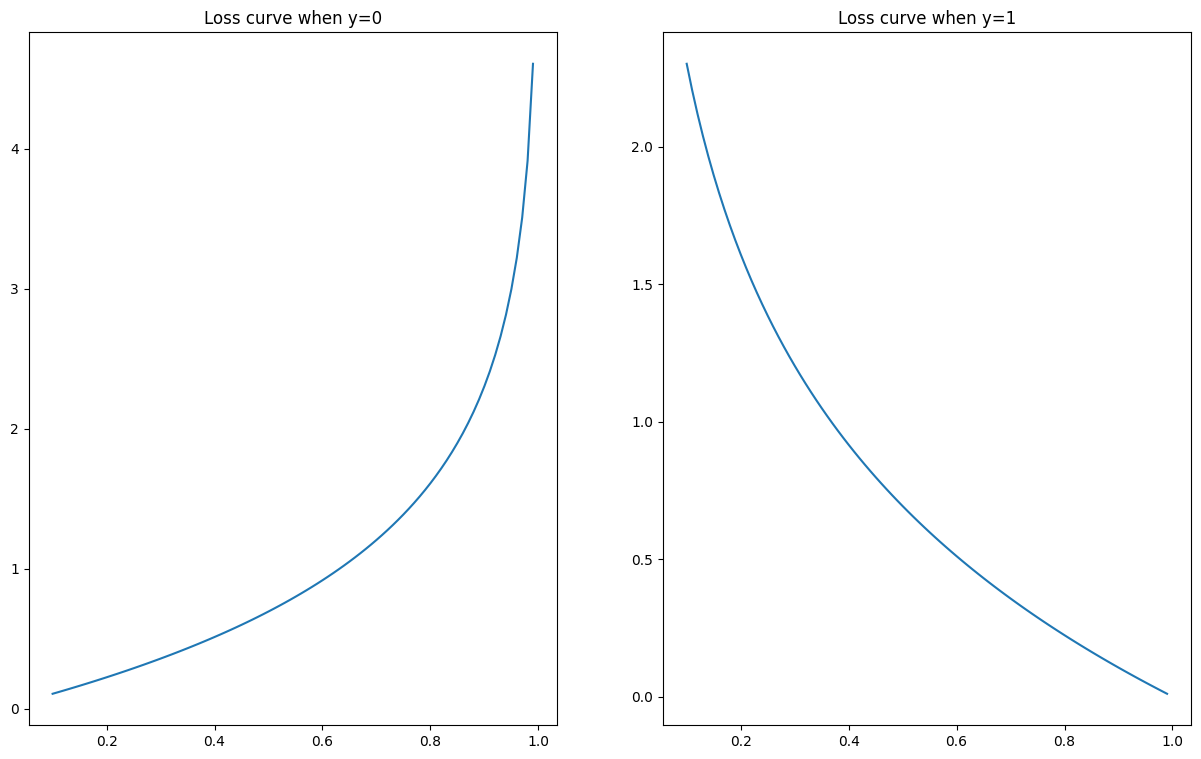

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 9))

y = np.arange(0.1, 1, 0.01)
l = -1 * np.log(1-y)

axes[0].plot(y, l)
axes[0].set_title("Loss curve when y=0")

y = np.arange(0.1, 1, 0.01)
l = -1 * np.log(y)

axes[1].plot(y, l)
axes[1].set_title("Loss curve when y=1")

In [17]:
# data processing

df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

# drop unneccessary columns
df_train = df_train.drop(columns=['Unnamed: 0', 'id'])
df_test = df_test.drop(columns=['Unnamed: 0', 'id'])

# drop missing values
df_train = df_train.dropna()
df_test = df_test.dropna()

# convert Arrival Delay in Minutes to integer
df_train['Arrival Delay in Minutes'] = df_train['Arrival Delay in Minutes'].astype(np.int64)
df_test['Arrival Delay in Minutes'] = df_test['Arrival Delay in Minutes'].astype(np.int64)

# divide categorical and numerical features
cat_feats = []
num_feats = []

for col, dtype in dict(df_train.dtypes).items():
    if dtype == np.dtypes.ObjectDType:
        cat_feats.append(col)
    elif dtype == np.int64:
        num_feats.append(col)

target = 'satisfaction'
cat_feats.remove(target)

# prepare train and test sets
train_features = cat_feats + num_feats

for cf in cat_feats+[target]:
    cats = list(df_train[cf].unique())
    cats.sort()
    encoder = OrdinalEncoder(categories=[cats])
    df_train[cf] = encoder.fit_transform(df_train[[cf]]).astype(int)
    
    cats = list(df_test[cf].unique())
    cats.sort()
    encoder = OrdinalEncoder(categories=[cats])
    df_test[cf] = encoder.fit_transform(df_test[[cf]]).astype(int)
       
X_train = df_train[train_features]
y_train = df_train[target]

X_test = df_test[train_features]
y_test = df_test[target]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(103594, 22) (103594,)
(25893, 22) (25893,)


In [29]:
clf = LogisticRegression(random_state=42)

pipe = make_pipeline(StandardScaler(), clf)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)

print(f"train accuracy: {accuracy}\n")

y_pred = pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"test accuracy: {accuracy}\n")

print("confusion matrix:")
print(cm)

train accuracy: 0.8755526381836786

test accuracy: 0.8709689877573089

confusion matrix:
[[13090  1438]
 [ 1903  9462]]


## Metrics

Accuracy, the proportion of all classifications that were correct, whether positive or negative:<br>
$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$<br><br>

Recall, true positive rate (TPR), or the proportion of all actual positives that were classified correctly as positives:<br>
$Recall(TPR) = \frac{TP}{TP+FN}$<br><br>

False Positive Rate (FPR), the proportion of all actual negatives that were classified incorrectly as positives, also known as the probability of false alarm:<br>
$FPR = \frac{FP}{TN+FP}$<br><br>

Precision, the proportion of all the model's positive classifications that are actually positive:<br>
$Precision = \frac{TP}{TP+FP}$<br><br>

F1 score or F1 measure, a single performance metric that takes both precision and recall into account:<br>
$F1 = \frac{2.Precision.Recall}{Precision+Recall}$<br><br>

ROC curve, a curve plotted between TPR and FPR, giving a visual representation of the performance of the model.<br><br>

AUC, area under ROC curve, giving a single score representing the integral under ROC curve. Score is between 0 and 1 with better the performance closer to 1.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89     14528
           1       0.87      0.83      0.85     11365

    accuracy                           0.87     25893
   macro avg       0.87      0.87      0.87     25893
weighted avg       0.87      0.87      0.87     25893



/Users/kaunghtetmyat/workspace_personal/stats-with-python/classification/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


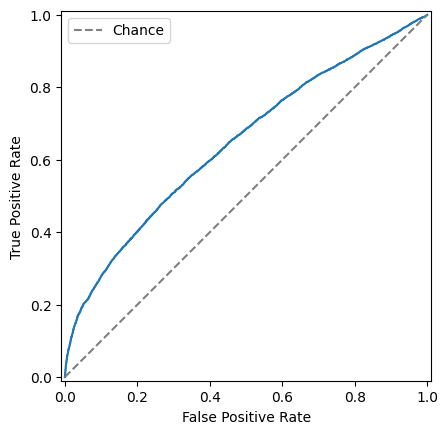

In [54]:
from sklearn.metrics import roc_curve, RocCurveDisplay

y_pred_proba = clf.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.legend()
plt.show()

In [53]:
from sklearn.metrics import roc_auc_score

score = roc_auc_score(y_test, y_pred)
print(f"AUC score: {score}")

AUC score: 0.866787407867884
